# Lab 19: Tree-Based Models — Random Forests
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Compare a single decision tree, Ridge regression, and Random Forest on the same dataset
- Tune Random Forest hyperparameters via cross-validation
- Extract and interpret feature importance (MDI and permutation)
- Apply the Ch 18 evaluation toolkit (confusion matrix, AUC) to a RF classifier

**Dataset:** California Housing (sklearn) — recurring thread from Ch 4, 12-16

**Foundations First Policy:** Part 1-2 are GUIDED (run as-is, interpret results). Part 3 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

---

## Setup

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load California Housing data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load California Housing (you've seen this dataset since Ch 4)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} observations')
print(f'Features: {list(X.columns)}')

Training set: 16512 observations, 8 features
Test set: 4128 observations
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Part 1: Decision Tree vs. Random Forest vs. Ridge (GUIDED — 10 min)

We compare three models on the same data. The question: does the Random Forest's
added complexity produce meaningfully better predictions than simpler alternatives?

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Train and compare Decision Tree, Ridge, and RF
# -----------------------------------------------------------

# 1. Unrestricted Decision Tree (high variance, low bias)
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

# 2. Ridge Regression (Ch 16 callback — stable but linear)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# 3. Random Forest (100 trees, default settings)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Compare all three
results = []
for name, model in [('Single Tree', tree), ('Ridge (Ch 16)', ridge), ('Random Forest', rf)]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R\u00b2': r2_score(y_train, train_pred),
        'Test R\u00b2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

               Train RMSE  Test RMSE  Train R²  Test R²
Model                                                  
Single Tree        0.0000     0.7069    1.0000   0.6187
Ridge (Ch 16)      0.7197     0.7455    0.6126   0.5759
Random Forest      0.1880     0.5057    0.9735   0.8049


### Interpretation Questions (answer in a markdown cell below)

1. Which model has the largest gap between Train R² and Test R²? What does this tell you about its variance?
2. The Random Forest's Test R² is substantially higher than Ridge. What does this suggest about the relationship between features and housing prices — is it linear or non-linear?
3. **Callback to Ch 15:** Where does each model sit on the bias-variance U-curve?

*Your answers here:*

1. Single tree had the largest gap, meaning the variance was the widest. 
2. This suggests the relationship is non-linear
3. Single tree has highest bias, then random forest, though it more closely fits the data (r2) and finally Lasso Ridge

## Part 2: Feature Importance — MDI vs. Permutation (GUIDED — 10 min)

Random Forests tell us which features matter most for prediction.
But remember: **predictive importance ≠ causal importance.**

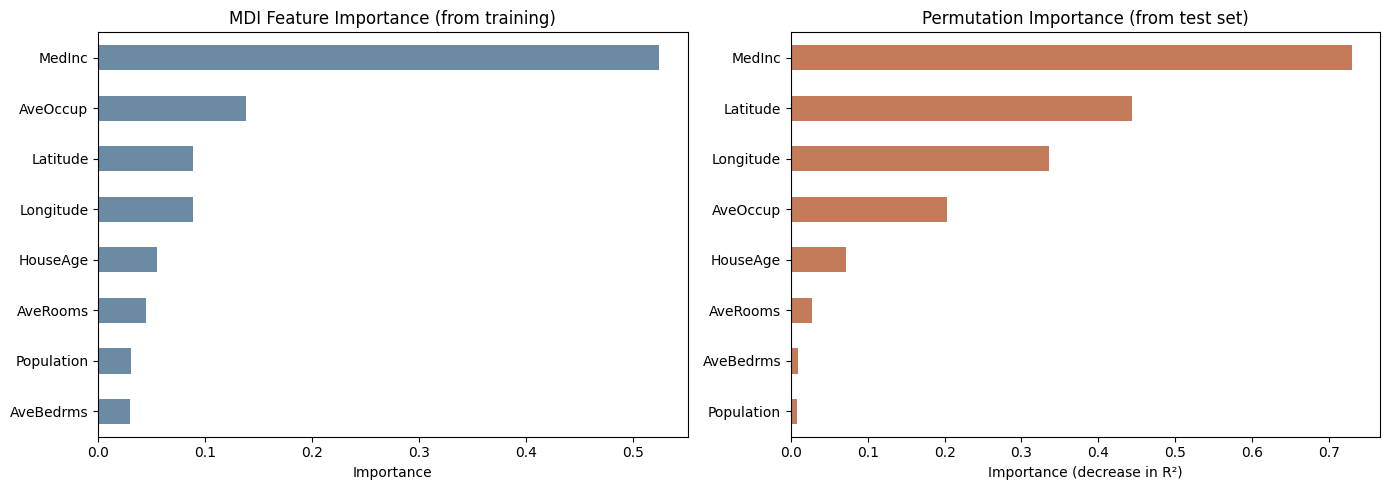


Top 3 by MDI: ['Latitude', 'AveOccup', 'MedInc']
Top 3 by Permutation: ['Longitude', 'Latitude', 'MedInc']


In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Compare MDI and permutation feature importance
# -----------------------------------------------------------
mdi_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI importance
mdi_importance.plot.barh(ax=axes[0], color='#6B8BA4')
axes[0].set_title('MDI Feature Importance (from training)', fontsize=12)
axes[0].set_xlabel('Importance')

# Permutation importance (more reliable — uses test set)
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

perm_importance.plot.barh(ax=axes[1], color='#C47B5A')
axes[1].set_title('Permutation Importance (from test set)', fontsize=12)
axes[1].set_xlabel('Importance (decrease in R\u00b2)')

plt.tight_layout()
plt.savefig('figures/ch19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 by MDI:', mdi_importance.tail(3).index.tolist())
print('Top 3 by Permutation:', perm_importance.tail(3).index.tolist())

### Interpretation Questions

1. Do MDI and permutation importance agree on the top features? Where do they diverge?
2. Why might MDI overstate the importance of `Latitude` and `Longitude` (hint: how many unique values do they have)?
3. **Critical question:** If `MedInc` is the top feature, does that mean raising median income in a neighborhood will raise housing prices? Why or why not? (Hint: Chapter 10 DAGs)

*Your answers here:*

1. Permutation values geolocation higher 
2. it has a class imbalance, more than the other
3. no not causal

## Part 3: Hyperparameter Tuning & Classification (YOUR TASK — 10 min)

Now YOU tune a Random Forest and apply it to a classification problem.

In [5]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune the Random Forest with GridSearchCV
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5, None],  # sqrt = sqrt(p), 0.5 = half, None = all
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}')

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
test_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f'Tuned RF \u2014 Test RMSE: {test_rmse:.4f}, Test R\u00b2: {test_r2:.4f}')

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV RMSE: 0.4965
Tuned RF — Test RMSE: 0.4955, Test R²: 0.8126


In [6]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Classification: Predict expensive homes (> median)
# -----------------------------------------------------------

# Create binary target: 1 if price > median, 0 otherwise
median_price = np.median(y)
y_binary = (y > median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

# Fit RF classifier and Logistic Regression (Ch 17 callback)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_c, y_train_c)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c, y_train_c)

# Compare AUC (Ch 18 evaluation toolkit)
for name, model in [('Logistic Regression (Ch 17)', log_reg), ('Random Forest', rf_clf)]:
    y_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)
    print(f'{name:35s} \u2014 AUC: {auc:.4f}')

Logistic Regression (Ch 17)         — AUC: 0.9057
Random Forest                       — AUC: 0.9609


### Final Interpretation

1. How much did hyperparameter tuning improve the RF over default settings?
2. Does the RF classifier beat logistic regression on AUC? Is the difference practically significant?
3. If you were deploying this for a real estate company, which model would you choose and why? Consider: accuracy, interpretability, maintenance cost.

*Your answers here:*

1. improved AUC by 0.06 which is a lot. 
2. Yes it is practically signifact much closer to 1, matter as we approach perfect. 
3. I would likely choose the Random forrest since it seems to more accurately depict pricing

---

## Extension (Optional — 15 min): Partial Dependence Plots

Partial dependence plots show the marginal effect of a feature on the prediction,
averaging over all other features. This reveals non-linearities the RF captures.

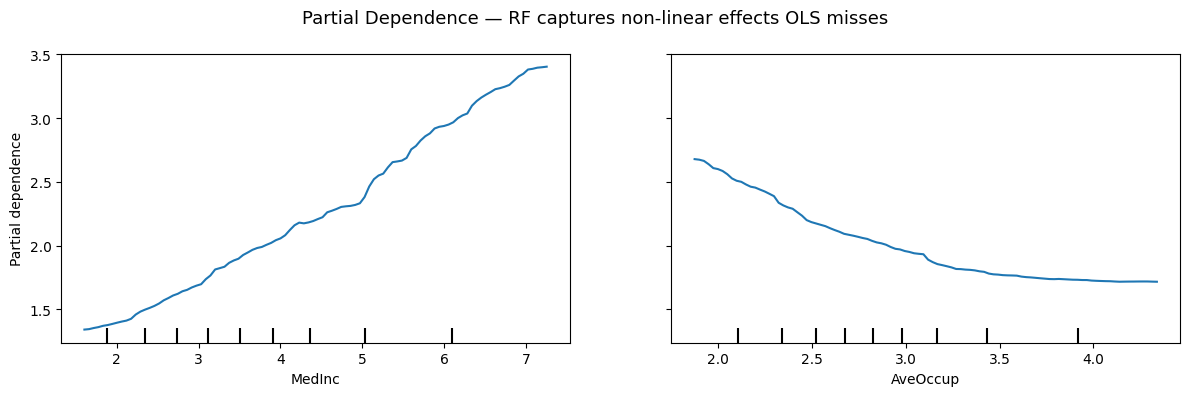

In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Partial dependence plots for top features
# -----------------------------------------------------------
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=['MedInc', 'AveOccup'],
    kind='average', ax=ax
)
plt.suptitle('Partial Dependence \u2014 RF captures non-linear effects OLS misses', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ch19_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## AI-Assisted Expansion: Interactive Random Forest Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, and feature importance. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive Streamlit app (or Plotly dashboard with ipywidgets) that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See the prediction surface update in real-time
3. Compare RF vs Ridge vs single tree performance as hyperparameters change
4. Display feature importance that updates with each parameter change

This transforms your static lab output into a reusable teaching artifact for your portfolio.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in interactive visualizations and scikit-learn.
#
# [Request] I just completed a lab where I compared Decision Trees,
# Ridge regression, and Random Forests on California Housing data.
# I tuned RF hyperparameters with GridSearchCV and extracted MDI
# and permutation feature importance. Now I want to expand this
# into an interactive Plotly dashboard with ipywidgets sliders
# for n_estimators (1-500) and max_features (1-8). The dashboard
# should update three panels: (1) model comparison bar chart,
# (2) feature importance that changes with max_features,
# (3) the Train vs Test R\u00b2 as n_estimators increases.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, numpy, sklearn.
# Use the same variable names: X_train, X_test, y_train, y_test,
# data.feature_names. Do not use deprecated Plotly functions.
#
# [Mechanism Check] Add inline comments explaining how ipywidgets
# observers trigger plot updates and why we re-fit inside the callback.
#
# [Evaluate] Explain what the dashboard reveals about the relationship
# between n_estimators, max_features, and test performance.

# PASTE AI-GENERATED CODE BELOW:


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.